In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
# import libraries

In [ ]:
import pandas as pd

In [ ]:
spark = SparkSession.builder \
        .appName("Titanic EDA") \
        .master("local[*]") \
        .getOrCreate()

In [ ]:
df = spark.read.csv(
    "/content/train.csv",
    header=True,
    inferSchema=True
    )

In [ ]:
df.show()

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05| NULL|       S|
|          6|       0|     3|    Moran, Mr. James|  male|NULL|    0|    0|      

In [ ]:
df.show(10)

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|
|          3|       1|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|
|          4|       1|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|
|          5|       0|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05| NULL|       S|
|          6|       0|     3|    Moran, Mr. James|  male|NULL|    0|    0|      

In [ ]:
df.printSchema()

root
 |-- PassengerId: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Pclass: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Ticket: string (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Cabin: string (nullable = true)
 |-- Embarked: string (nullable = true)



In [ ]:
df.count()

891

In [ ]:
len(df.columns)
# number of columns

12

In [ ]:
df.columns
# colomn names

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [ ]:
df.describe().show()
#summary statistics

+-------+-----------------+-------------------+------------------+--------------------+------+------------------+------------------+-------------------+------------------+-----------------+-----+--------+
|summary|      PassengerId|           Survived|            Pclass|                Name|   Sex|               Age|             SibSp|              Parch|            Ticket|             Fare|Cabin|Embarked|
+-------+-----------------+-------------------+------------------+--------------------+------+------------------+------------------+-------------------+------------------+-----------------+-----+--------+
|  count|              891|                891|               891|                 891|   891|               714|               891|                891|               891|              891|  204|     889|
|   mean|            446.0| 0.3838383838383838| 2.308641975308642|                NULL|  NULL| 29.69911764705882|0.5230078563411896|0.38159371492704824|260318.54916792738| 32.20420

In [ ]:
df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()
# missing values

+-----------+--------+------+----+---+---+-----+-----+------+----+-----+--------+
|PassengerId|Survived|Pclass|Name|Sex|Age|SibSp|Parch|Ticket|Fare|Cabin|Embarked|
+-----------+--------+------+----+---+---+-----+-----+------+----+-----+--------+
|          0|       0|     0|   0|  0|177|    0|    0|     0|   0|  687|       2|
+-----------+--------+------+----+---+---+-----+-----+------+----+-----+--------+



In [ ]:
print("Total:", df.count())
print("Distinct:",df.distinct().count())
#find duplcates

Total: 891
Distinct: 891


In [ ]:
df =df.dropDuplicates()
#drop duplicates

In [ ]:
df.dtypes

[('PassengerId', 'int'),
 ('Survived', 'int'),
 ('Pclass', 'int'),
 ('Name', 'string'),
 ('Sex', 'string'),
 ('Age', 'double'),
 ('SibSp', 'int'),
 ('Parch', 'int'),
 ('Ticket', 'string'),
 ('Fare', 'double'),
 ('Cabin', 'string'),
 ('Embarked', 'string')]

In [ ]:
df.filter(
    col("Age") > 50
).show()
#passengers older than 50

+-----------+--------+------+--------------------+------+----+-----+-----+---------+-------+-----------+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|   Ticket|   Fare|      Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+---------+-------+-----------+--------+
|        488|       0|     1|Kent, Mr. Edward ...|  male|58.0|    0|    0|    11771|   29.7|        B37|       C|
|        171|       0|     1|Van der hoef, Mr....|  male|61.0|    0|    0|   111240|   33.5|        B19|       S|
|        263|       0|     1|   Taussig, Mr. Emil|  male|52.0|    1|    1|   110413|  79.65|        E67|       S|
|        253|       0|     1|Stead, Mr. Willia...|  male|62.0|    0|    0|   113514|  26.55|        C87|       S|
|         55|       0|     1|Ostby, Mr. Engelh...|  male|65.0|    0|    1|   113509|61.9792|        B30|       C|
|        766|       1|     1|Hogeboom, Mrs. Jo...|female|51.0|    1|    0|    13502|77.9

In [ ]:
df.filter(
    (col("sex")=="female") &
    (col("survived")==1)
    ).show()
  #multiple conditions


+-----------+--------+------+--------------------+------+----+-----+-----+----------+--------+-----------+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|    Ticket|    Fare|      Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------+--------+-----------+--------+
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|  PC 17599| 71.2833|        C85|       C|
|        292|       1|     1|Bishop, Mrs. Dick...|female|19.0|    1|    0|     11967| 91.0792|        B49|       C|
|        330|       1|     1|Hippach, Miss. Je...|female|16.0|    0|    1|    111361| 57.9792|        B18|       C|
|        394|       1|     1|Newell, Miss. Mar...|female|23.0|    1|    0|     35273| 113.275|        D36|       C|
|        270|       1|     1|Bissette, Miss. A...|female|35.0|    0|    0|  PC 17760|135.6333|        C99|       S|
|        370|       1|     1|Aubart, Mme. Leon...|female|24.0|    0|    

In [ ]:
df.orderBy(
    col("Fare").desc()
).show()
#highest fare

+-----------+--------+------+--------------------+------+----+-----+-----+--------+--------+---------------+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|  Ticket|    Fare|          Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+--------+--------+---------------+--------+
|        680|       1|     1|Cardeza, Mr. Thom...|  male|36.0|    0|    1|PC 17755|512.3292|    B51 B53 B55|       C|
|        738|       1|     1|Lesurer, Mr. Gust...|  male|35.0|    0|    0|PC 17755|512.3292|           B101|       C|
|        259|       1|     1|    Ward, Miss. Anna|female|35.0|    0|    0|PC 17755|512.3292|           NULL|       C|
|        439|       0|     1|   Fortune, Mr. Mark|  male|64.0|    1|    4|   19950|   263.0|    C23 C25 C27|       S|
|         28|       0|     1|Fortune, Mr. Char...|  male|19.0|    3|    2|   19950|   263.0|    C23 C25 C27|       S|
|         89|       1|     1|Fortune, Miss. Ma...|female

In [ ]:
df.orderBy(
    col("Age")
).show()
#oldest passenger

+-----------+--------+------+--------------------+------+----+-----+-----+-----------------+--------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|           Ticket|    Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+-----------------+--------+-----+--------+
|        553|       0|     3|O'Brien, Mr. Timothy|  male|NULL|    0|    0|           330979|  7.8292| NULL|       Q|
|        486|       0|     3|Lefebre, Miss. Je...|female|NULL|    3|    1|             4133| 25.4667| NULL|       S|
|        465|       0|     3|  Maisner, Mr. Simon|  male|NULL|    0|    0|         A/S 2816|    8.05| NULL|       S|
|         65|       0|     1|Stewart, Mr. Albe...|  male|NULL|    0|    0|         PC 17605| 27.7208| NULL|       C|
|        508|       1|     1|"Bradley, Mr. Geo...|  male|NULL|    0|    0|           111427|   26.55| NULL|       S|
|        565|       0|     3|Meanwell, Miss. (...|female|NULL|  

In [ ]:
df.groupBy("sex").count().show()
#number of passengers by gender

+------+-----+
|   sex|count|
+------+-----+
|female|  314|
|  male|  577|
+------+-----+



In [ ]:
df.groupBy("Pclass").agg(
    avg("Fare").alias("Average Fare")
).show()

+------+------------------+
|Pclass|      Average Fare|
+------+------------------+
|     1| 84.15468749999998|
|     3|   13.675550101833|
|     2|20.662183152173913|
+------+------------------+



In [ ]:
df.groupBy("Pclass").agg(
    count("*").alias("Passengers"),
    avg("Fare").alias("Average Fare"),
    max("Fare").alias("Highest Fare"),
    min("Fare").alias("Lowest Fare"),
    avg("Age").alias("Average Age")
).show()


+------+----------+------------------+------------+-----------+------------------+
|Pclass|Passengers|      Average Fare|Highest Fare|Lowest Fare|       Average Age|
+------+----------+------------------+------------+-----------+------------------+
|     1|       216| 84.15468749999998|    512.3292|        0.0|38.233440860215055|
|     3|       491|   13.675550101833|       69.55|        0.0| 25.14061971830986|
|     2|       184|20.662183152173913|        73.5|        0.0| 29.87763005780347|
+------+----------+------------------+------------+-----------+------------------+



In [ ]:
df = df.withColumn(
    "Familysize",
    col("sibsp")+col("parch")+1
)
df.show()
# create new columns

+-----------+--------+------+--------------------+------+----+-----+-----+-------------+--------+-----------+--------+----------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|       Ticket|    Fare|      Cabin|Embarked|Familysize|
+-----------+--------+------+--------------------+------+----+-----+-----+-------------+--------+-----------+--------+----------+
|          2|       1|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|     PC 17599| 71.2833|        C85|       C|         2|
|         24|       1|     1|Sloper, Mr. Willi...|  male|28.0|    0|    0|       113788|    35.5|         A6|       S|         1|
|        680|       1|     1|Cardeza, Mr. Thom...|  male|36.0|    0|    1|     PC 17755|512.3292|B51 B53 B55|       C|         2|
|        292|       1|     1|Bishop, Mrs. Dick...|female|19.0|    1|    0|        11967| 91.0792|        B49|       C|         2|
|        330|       1|     1|Hippach, Miss. Je...|female|16.0|    0|    1|       111361| 5

In [ ]:
df.stat.corr(
    "Age",
    "Fare"
)
#correlation between age and fare

0.13551585352705078

In [ ]:
df.write.mode("overwrite") \
.option("header", "true") \
.csv("Titanic_clean")

Visualization


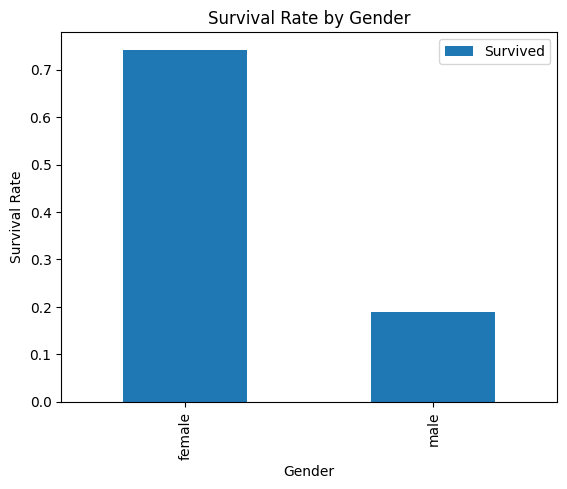

In [ ]:
import matplotlib.pyplot as plt
pdf = df.toPandas()
pd.DataFrame(pdf.groupby("Sex")["Survived"].mean()).plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.xlabel("Gender")
plt.show()

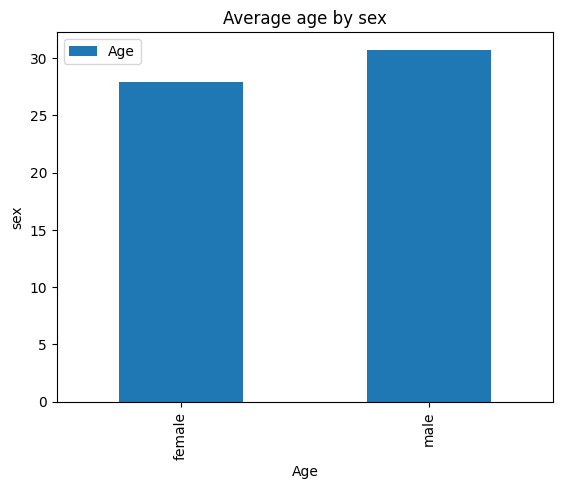

In [ ]:
import matplotlib.pyplot as plt
pdf = df.toPandas()
pd.DataFrame(pdf.groupby("Sex")["Age"].mean()).plot(kind="bar")
plt.title("Average age by sex")
plt.ylabel("sex")
plt.xlabel("Age")
plt.show()

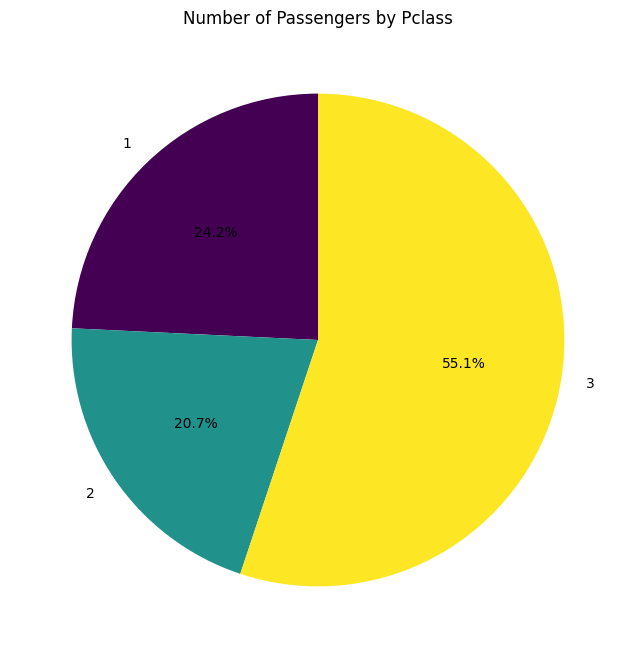

In [ ]:
import matplotlib.pyplot as plt

# Ensure pdf is updated from the current df if any modifications happened
pdf = df.toPandas()

# Group by Pclass and count passengers
pclass_counts = pdf['Pclass'].value_counts().sort_index()

# Create a pie chart
plt.figure(figsize=(8, 8))
pclass_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Number of Passengers by Pclass')
plt.ylabel('') # Hide the default ylabel to avoid confusion with pie chart
plt.show()